In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import sys
sys.path.append("../scripts")

# Cargar datos procesados
era5  = xr.open_dataset("../datos/procesados/era5_procesado.nc")
oisst = xr.open_dataset("../datos/procesados/oisst_procesado.nc")
mld   = xr.open_dataset("../datos/procesados/mld_procesado.nc")

print("ERA5:", era5)
print("OISST:", oisst)
print("MLD:", mld)

ERA5: <xarray.Dataset> Size: 308MB
Dimensions:    (time: 16071, latitude: 33, longitude: 29)
Coordinates:
  * time       (time) datetime64[ns] 129kB 1980-01-01 1980-01-02 ... 2023-12-31
  * latitude   (latitude) float64 264B 8.0 7.75 7.5 7.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 232B -82.0 -81.75 -81.5 ... -75.25 -75.0
Data variables:
    t2m        (time, latitude, longitude) float32 62MB ...
    q          (time, latitude, longitude) float32 62MB ...
    wspd       (time, latitude, longitude) float32 62MB ...
    sw         (time, latitude, longitude) float32 62MB ...
    lw         (time, latitude, longitude) float32 62MB ...
OISST: <xarray.Dataset> Size: 59MB
Dimensions:    (time: 15340, latitude: 33, longitude: 29)
Coordinates:
  * time       (time) datetime64[ns] 123kB 1982-01-01 1982-01-02 ... 2023-12-31
  * latitude   (latitude) float32 132B 0.125 0.375 0.625 ... 7.625 7.875 8.125
  * longitude  (longitude) float32 116B -82.12 -81.88 -81.62 ... -75.38 -75.12

In [2]:
# Pixel de prueba: 4N, 80W
lat0, lon0 = 4.0, -80.0

t2m_px  = era5["t2m"].sel(latitude=lat0,  longitude=lon0, method="nearest").values
q_px    = era5["q"].sel(latitude=lat0,    longitude=lon0, method="nearest").values
wspd_px = era5["wspd"].sel(latitude=lat0, longitude=lon0, method="nearest").values
sw_px   = era5["sw"].sel(latitude=lat0,   longitude=lon0, method="nearest").values
lw_px   = era5["lw"].sel(latitude=lat0,   longitude=lon0, method="nearest").values
h_clim  = mld["mld"].sel(latitude=lat0,   longitude=lon0, method="nearest").values
sst_obs = oisst["sst"].sel(latitude=lat0, longitude=lon0, method="nearest").values

# Recortar ERA5 al periodo OISST (1982-2023)
idx_ini = np.where(era5.time.values == np.datetime64("1982-01-01"))[0][0]
t2m_px  = t2m_px[idx_ini:]
q_px    = q_px[idx_ini:]
wspd_px = wspd_px[idx_ini:]
sw_px   = sw_px[idx_ini:]
lw_px   = lw_px[idx_ini:]

print(f"SST inicial observada: {sst_obs[0]:.2f} °C")
print(f"h_clim 12 meses: {h_clim.round(1)}")
print(f"Dias de forzamiento: {len(t2m_px)}")
print(f"t2m  rango: {t2m_px.min():.2f} -- {t2m_px.max():.2f} °C")
print(f"sw   rango: {sw_px.min():.2f} -- {sw_px.max():.2f} W/m2")
print(f"wspd rango: {wspd_px.min():.2f} -- {wspd_px.max():.2f} m/s")


SST inicial observada: 25.43 °C
h_clim 12 meses: [13.5 10.8 11.3 12.4 15.8 17.  17.1 17.  19.2 19.6 17.1 14.9]
Dias de forzamiento: 15340
t2m  rango: 21.67 -- 28.80 °C
sw   rango: 0.28 -- 62.47 W/m2
wspd rango: 0.06 -- 12.77 m/s


In [3]:
# Constantes fisicas
RHO_W   = 1025.0
CP_W    = 3994.0
RHO_A   = 1.2
CP_A    = 1005.0
EPSILON = 0.97
SIGMA   = 5.67e-8

def flujos_coare(sst, t2m, q, wspd):
    e_sat = 6.112 * np.exp(17.67 * sst / (sst + 243.5))
    q_sat = 0.622 * e_sat / (1013.25 - 0.378 * e_sat)
    dq    = q_sat - q
    dt    = sst - t2m
    wspd  = np.maximum(wspd, 0.5)
    Cd    = 1e-3 * (0.61 + 0.063 * wspd)
    Ch    = 1.3e-3
    Ce    = 1.15e-3
    Lv    = 2.5e6
    Ql    = RHO_A * Lv   * Ce * wspd * dq
    Qs    = RHO_A * CP_A * Ch * wspd * dt
    tau   = RHO_A * Cd * wspd**2
    return Ql, Qs, tau

def flujo_neto(sst, sw, lw, Ql, Qs):
    albedo = 0.06
    Qsw    = (1 - albedo) * sw
    sst_k  = sst + 273.15
    Qlw    = lw - EPSILON * SIGMA * sst_k**4
    Qnet   = Qsw + Qlw - Ql - Qs
    return Qnet, Qsw, Qlw

def correr_modelo(t2m, q, wspd, sw, lw, h_clim, sst_ini, tiempo, dt=86400.0):
    n       = len(t2m)
    sst_sim = np.full(n, np.nan)
    qnet    = np.full(n, np.nan)
    sst     = sst_ini

    for i in range(n):
        mes = tiempo[i].astype("datetime64[M]").astype(int) % 12  # 0-11
        h   = h_clim[mes]
        Ql, Qs, tau      = flujos_coare(sst, t2m[i], q[i], wspd[i])
        Qnet, Qsw, Qlw   = flujo_neto(sst, sw[i], lw[i], Ql, Qs)
        dT               = (Qnet * dt) / (RHO_W * CP_W * h)
        T_sub            = sst - 1.0
        we               = np.maximum(-Qnet, 0.0) / (RHO_W * CP_W * max(sst - T_sub, 0.1))
        Q_ent            = RHO_W * CP_W * we * (sst - T_sub)
        dT              -= (Q_ent * dt) / (RHO_W * CP_W * h)
        sst             += dT
        sst_sim[i]       = sst
        qnet[i]          = Qnet

    return sst_sim, qnet

print("Funciones definidas.")

Funciones definidas.


In [4]:
# Diagnostico balance energetico con datos corregidos
print("=== Diagnostico balance energetico (promedio primer año) ===")
Ql, Qs, tau = flujos_coare(sst_obs[:365].mean(), t2m_px[:365].mean(),
                            q_px[:365].mean(), wspd_px[:365].mean())
Qnet, Qsw, Qlw = flujo_neto(sst_obs[:365].mean(), sw_px[:365].mean(),
                             lw_px[:365].mean(), Ql, Qs)

sst_k = sst_obs[:365].mean() + 273.15
Qlw_emitido = EPSILON * SIGMA * sst_k**4

print(f"SW descendente medio:     {sw_px[:365].mean():.1f} W/m2")
print(f"LW descendente medio:     {lw_px[:365].mean():.1f} W/m2")
print(f"LW emitido por oceano:    {Qlw_emitido:.1f} W/m2")
print(f"LW neto:                  {Qlw:.1f} W/m2")
print(f"SW neto:                  {Qsw:.1f} W/m2")
print(f"Calor latente:            {Ql:.1f} W/m2")
print(f"Calor sensible:           {Qs:.1f} W/m2")
print(f"Qnet total:               {Qnet:.1f} W/m2")

=== Diagnostico balance energetico (promedio primer año) ===
SW descendente medio:     19.0 W/m2
LW descendente medio:     421.0 W/m2
LW emitido por oceano:    445.1 W/m2
LW neto:                  -24.1 W/m2
SW neto:                  17.9 W/m2
Calor latente:            54.9 W/m2
Calor sensible:           7.4 W/m2
Qnet total:               -68.5 W/m2


In [5]:
# Verificar factor de escala necesario
# SW medio diario tipico tropical: ~180-220 W/m2 (Wild et al 2013)
# Nuestro SW medio: 19 W/m2
# Factor necesario: ~10

print(f"SW medio actual:          {sw_px[:365].mean():.1f} W/m2")
print(f"Factor x2:                {sw_px[:365].mean()*2:.1f} W/m2")
print(f"Factor x pi/2:            {sw_px[:365].mean()*np.pi/2:.1f} W/m2")
print(f"Factor x10:               {sw_px[:365].mean()*10:.1f} W/m2")

# Revisar el atributo de la variable en el archivo
print("\nAtributos SW en era5_procesado:")
print(era5["sw"].attrs)

SW medio actual:          19.0 W/m2
Factor x2:                38.0 W/m2
Factor x pi/2:            29.8 W/m2
Factor x10:               189.9 W/m2

Atributos SW en era5_procesado:
{'GRIB_paramId': np.int64(235035), 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': np.int64(957), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'avg', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(29), 'GRIB_Ny': np.int64(33), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'avg_sdswrf', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(8.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(0.0), 'GRIB_longitudeOfFirstGridPointI

In [6]:
import xarray as xr
ds = xr.open_dataset("../datos/ERA5/era5_surface_solar_radiation_downwards_1980.nc")
print(ds.valid_time.values[:10])
print(ds["ssrd"].values[:10, 16, 14])

['1980-01-01T00:00:00.000000000' '1980-01-01T03:00:00.000000000'
 '1980-01-01T06:00:00.000000000' '1980-01-01T09:00:00.000000000'
 '1980-01-01T12:00:00.000000000' '1980-01-01T15:00:00.000000000'
 '1980-01-01T18:00:00.000000000' '1980-01-01T21:00:00.000000000'
 '1980-01-02T00:00:00.000000000' '1980-01-02T03:00:00.000000000']
[3.392000e+03 0.000000e+00 0.000000e+00 0.000000e+00 4.953600e+04
 1.265472e+06 9.541120e+05 5.864320e+05 1.536000e+03 0.000000e+00]


In [7]:
# Calcular SW diario como maximo del acumulado de cada dia
# (el maximo ocurre al final del dia antes del reinicio nocturno)
vals_dia1 = ds["ssrd"].values[:8, 16, 14]
print("Acumulados dia 1 (J/m2):", vals_dia1.round(0))
print("Maximo (= total del dia):", vals_dia1.max().round(0))
print("Flujo medio diario (W/m2):", (vals_dia1.max() / 86400).round(1))

vals_dia2 = ds["ssrd"].values[8:16, 16, 14]
print("\nAcumulados dia 2 (J/m2):", vals_dia2.round(0))
print("Maximo:", vals_dia2.max().round(0))
print("Flujo medio diario (W/m2):", (vals_dia2.max() / 86400).round(1))

Acumulados dia 1 (J/m2): [3.392000e+03 0.000000e+00 0.000000e+00 0.000000e+00 4.953600e+04
 1.265472e+06 9.541120e+05 5.864320e+05]
Maximo (= total del dia): 1.265472e+06
Flujo medio diario (W/m2): 14.6

Acumulados dia 2 (J/m2): [  1536.      0.      0.      0.  12736. 401472. 492032. 792768.]
Maximo: 792768.0
Flujo medio diario (W/m2): 9.2


In [8]:
# Verificar patron de reinicio
print("Dia 1 completo con timestamps:")
for i in range(8):
    t = ds.valid_time.values[i]
    v = ds["ssrd"].values[i, 16, 14]
    print(f"  {t}  {v:.0f} J/m2")

print("\nDia 2:")
for i in range(8, 16):
    t = ds.valid_time.values[i]
    v = ds["ssrd"].values[i, 16, 14]
    print(f"  {t}  {v:.0f} J/m2")

Dia 1 completo con timestamps:
  1980-01-01T00:00:00.000000000  3392 J/m2
  1980-01-01T03:00:00.000000000  0 J/m2
  1980-01-01T06:00:00.000000000  0 J/m2
  1980-01-01T09:00:00.000000000  0 J/m2
  1980-01-01T12:00:00.000000000  49536 J/m2
  1980-01-01T15:00:00.000000000  1265472 J/m2
  1980-01-01T18:00:00.000000000  954112 J/m2
  1980-01-01T21:00:00.000000000  586432 J/m2

Dia 2:
  1980-01-02T00:00:00.000000000  1536 J/m2
  1980-01-02T03:00:00.000000000  0 J/m2
  1980-01-02T06:00:00.000000000  0 J/m2
  1980-01-02T09:00:00.000000000  0 J/m2
  1980-01-02T12:00:00.000000000  12736 J/m2
  1980-01-02T15:00:00.000000000  401472 J/m2
  1980-01-02T18:00:00.000000000  492032 J/m2
  1980-01-02T21:00:00.000000000  792768 J/m2


In [9]:
# El timestep de las 12:00 UTC = acumulado de 24h desde 12:00 UTC dia anterior
# = flujo diario completo
sw_12 = ds["ssrd"].sel(valid_time=ds.valid_time[ds.valid_time.dt.hour == 12]).values[:, 16, 14]
print("SW a las 12:00 UTC primeros 5 dias (J/m2):", sw_12[:5].round(0))
print("Flujo diario (W/m2):", (sw_12[:5] / 86400).round(1))

lw_ds = xr.open_dataset("../datos/ERA5/era5_surface_thermal_radiation_downwards_1980.nc")
lw_12 = lw_ds["strd"].sel(valid_time=lw_ds.valid_time[lw_ds.valid_time.dt.hour == 12]).values[:, 16, 14]
print("\nLW a las 12:00 UTC primeros 5 dias (J/m2):", lw_12[:5].round(0))
print("Flujo diario (W/m2):", (lw_12[:5] / 86400).round(1))

SW a las 12:00 UTC primeros 5 dias (J/m2): [49536. 12736. 21056. 44224. 47424.]
Flujo diario (W/m2): [0.6 0.1 0.2 0.5 0.5]

LW a las 12:00 UTC primeros 5 dias (J/m2): [1.531035e+06 1.543386e+06 1.540483e+06 1.528616e+06 1.511155e+06]
Flujo diario (W/m2): [17.7 17.9 17.8 17.7 17.5]


In [10]:
# El avg_sdswrf que descargamos: 19 W/m2 medio
# Comparar con CERES SYN1deg que ya usamos en proyecto 3
# En el tropico el SW descendente medio es ~185-220 W/m2

# Revisar si hay un step range en los atributos
sw_avg = xr.open_dataset("../datos/ERA5/era5_msdwswrf_1980_2023.nc")
print("GRIB_stepRange:", sw_avg["avg_sdswrf"].attrs.get("GRIB_stepRange", "no attr"))
print("GRIB_startStep:", sw_avg["avg_sdswrf"].attrs.get("GRIB_startStep", "no attr"))
print("GRIB_endStep:",   sw_avg["avg_sdswrf"].attrs.get("GRIB_endStep",   "no attr"))
print("GRIB_stepType:",  sw_avg["avg_sdswrf"].attrs.get("GRIB_stepType",  "no attr"))
print()
# Valor a las 12:00 UTC para enero 1980, pixel central
print("Valor 1980-01-01:", float(sw_avg["avg_sdswrf"].isel(valid_time=0, latitude=16, longitude=14)))

GRIB_stepRange: no attr
GRIB_startStep: no attr
GRIB_endStep: no attr
GRIB_stepType: avg

Valor 1980-01-01: 13.75


In [11]:
# SW diario = acumulado 21:00 UTC - acumulado 00:00 UTC del mismo dia
# Cubre 21 horas, incluyendo todas las horas de luz en UTC-5

dia1_00 = ds["ssrd"].values[0, 16, 14]   # 00:00 UTC
dia1_21 = ds["ssrd"].values[7, 16, 14]   # 21:00 UTC
dia2_00 = ds["ssrd"].values[8, 16, 14]   # 00:00 UTC dia siguiente

print(f"00:00 UTC dia 1: {dia1_00:.0f} J/m2")
print(f"21:00 UTC dia 1: {dia1_21:.0f} J/m2")
print(f"00:00 UTC dia 2: {dia2_00:.0f} J/m2")
print()
print(f"Diferencia 21:00 - 00:00 dia 1: {dia1_21 - dia1_00:.0f} J/m2")
print(f"Flujo medio diario: {(dia1_21 - dia1_00) / 86400:.1f} W/m2")
print()
# Verificar con dia 2
dia2_21 = ds["ssrd"].values[15, 16, 14]
print(f"Diferencia dia 2: {dia2_21 - dia2_00:.0f} J/m2")
print(f"Flujo medio diario dia 2: {(dia2_21 - dia2_00) / 86400:.1f} W/m2")

00:00 UTC dia 1: 3392 J/m2
21:00 UTC dia 1: 586432 J/m2
00:00 UTC dia 2: 1536 J/m2

Diferencia 21:00 - 00:00 dia 1: 583040 J/m2
Flujo medio diario: 6.7 W/m2

Diferencia dia 2: 791232 J/m2
Flujo medio diario dia 2: 9.2 W/m2


In [18]:
# Cargar CERES del proyecto 3 para comparar SW descendente
from pathlib import Path
import glob
ceres_dir = Path.cwd().parent.parent / 'proyecto 3' / 'datos' / 'ceres' / 'raw'
ceres_files = sorted(glob.glob(str(ceres_dir / '*.nc')))
print('Directorio CERES:', ceres_dir)
print("Archivos CERES disponibles:", len(ceres_files))
if ceres_files:
    ds_ceres = xr.open_dataset(ceres_files[0])
    print(ds_ceres)
else:
    print('No se encontraron archivos .nc en', ceres_dir)

Directorio CERES: /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3/datos/ceres/raw
Archivos CERES disponibles: 3
<xarray.Dataset> Size: 2GB
Dimensions:                              (time: 1466, lat: 180, lon: 360)
Coordinates:
  * time                                 (time) datetime64[ns] 12kB 2001-01-0...
  * lat                                  (lat) float32 720B -89.5 -88.5 ... 89.5
  * lon                                  (lon) float32 1kB 0.5 1.5 ... 359.5
Data variables:
    toa_net_all_daily                    (time, lat, lon) float32 380MB ...
    adj_atmos_sw_up_all_surface_daily    (time, lat, lon) float32 380MB ...
    adj_atmos_sw_down_all_surface_daily  (time, lat, lon) float32 380MB ...
    adj_atmos_lw_up_all_surface_daily    (time, lat, lon) float32 380MB ...
    adj_atmos_lw_down_all_surface_daily  (time, lat, lon) float32 380MB ...
Attributes:
    title:        CERES SYN1deg Daily data
    institution:  NASA Langley Research Center
    Conventions

In [19]:
# SW descendente superficie en CERES para region Pacifico colombiano
sw_ceres = ds_ceres["adj_atmos_sw_down_all_surface_daily"].sel(
    lat=slice(0, 8),
    lon=slice(278, 285)  # 0-360: 278-285 = 82-75W
).mean(dim=["lat", "lon"])

print(f"CERES SW descendente medio 2001-2009: {float(sw_ceres.mean()):.1f} W/m2")
print(f"CERES SW descendente min/max: {float(sw_ceres.min()):.1f} -- {float(sw_ceres.max()):.1f} W/m2")

# Comparar con ERA5 para el mismo periodo
era5_sw_periodo = era5["sw"].sel(
    time=slice("2001-01-01", "2009-12-31")
).mean(dim=["latitude", "longitude"])

print(f"\nERA5 SW medio 2001-2009: {float(era5_sw_periodo.mean()):.1f} W/m2")
print(f"Factor de escala necesario: {float(sw_ceres.mean()) / float(era5_sw_periodo.mean()):.1f}")

CERES SW descendente medio 2001-2009: 178.2 W/m2
CERES SW descendente min/max: 89.5 -- 262.2 W/m2

ERA5 SW medio 2001-2009: 25.8 W/m2
Factor de escala necesario: 6.9


In [20]:
# Verificar estabilidad del factor por año usando CERES 2001-2009
for year in range(2001, 2010):
    sw_c = ds_ceres["adj_atmos_sw_down_all_surface_daily"].sel(
        lat=slice(0, 8), lon=slice(278, 285),
        time=slice(f"{year}-01-01", f"{year}-12-31")
    ).mean(dim=["lat", "lon"])
    
    sw_e = era5["sw"].sel(
        time=slice(f"{year}-01-01", f"{year}-12-31")
    ).mean(dim=["latitude", "longitude"])
    
    factor = float(sw_c.mean()) / float(sw_e.mean())
    print(f"{year}: CERES={float(sw_c.mean()):.1f}  ERA5={float(sw_e.mean()):.1f}  factor={factor:.2f}")

2001: CERES=178.6  ERA5=25.8  factor=6.91
2002: CERES=178.7  ERA5=26.5  factor=6.74
2003: CERES=175.9  ERA5=25.4  factor=6.93
2004: CERES=179.5  ERA5=26.1  factor=6.88
2005: CERES=174.3  ERA5=25.6  factor=6.81
2006: CERES=nan  ERA5=25.9  factor=nan
2007: CERES=nan  ERA5=25.3  factor=nan
2008: CERES=nan  ERA5=25.6  factor=nan
2009: CERES=nan  ERA5=26.4  factor=nan


In [21]:
SW_FACTOR = 6.85

# Verificar balance con SW corregido
sw_corregido = sw_px[:365].mean() * SW_FACTOR
print(f"SW corregido medio: {sw_corregido:.1f} W/m2")

Ql, Qs, tau = flujos_coare(sst_obs[:365].mean(), t2m_px[:365].mean(),
                            q_px[:365].mean(), wspd_px[:365].mean())
Qnet, Qsw, Qlw = flujo_neto(sst_obs[:365].mean(), 
                             sw_px[:365].mean() * SW_FACTOR,
                             lw_px[:365].mean(), Ql, Qs)

sst_k = sst_obs[:365].mean() + 273.15
Qlw_emitido = EPSILON * SIGMA * sst_k**4

print(f"SW descendente medio:     {sw_px[:365].mean() * SW_FACTOR:.1f} W/m2")
print(f"LW descendente medio:     {lw_px[:365].mean():.1f} W/m2")
print(f"LW emitido por oceano:    {Qlw_emitido:.1f} W/m2")
print(f"LW neto:                  {Qlw:.1f} W/m2")
print(f"SW neto:                  {Qsw:.1f} W/m2")
print(f"Calor latente:            {Ql:.1f} W/m2")
print(f"Calor sensible:           {Qs:.1f} W/m2")
print(f"Qnet total:               {Qnet:.1f} W/m2")

SW corregido medio: 130.1 W/m2
SW descendente medio:     130.1 W/m2
LW descendente medio:     421.0 W/m2
LW emitido por oceano:    445.1 W/m2
LW neto:                  -24.1 W/m2
SW neto:                  122.3 W/m2
Calor latente:            54.9 W/m2
Calor sensible:           7.4 W/m2
Qnet total:               35.9 W/m2


In [23]:
sst_sim, qnet = correr_modelo(
    t2m_px, q_px, wspd_px,
    sw_px * SW_FACTOR,
    lw_px,
    h_clim, sst_ini=sst_obs[0],
    tiempo=oisst.time.values
)

print(f"SST simulada rango: {np.nanmin(sst_sim):.2f} -- {np.nanmax(sst_sim):.2f} °C")
print(f"SST observada rango: {np.nanmin(sst_obs):.2f} -- {np.nanmax(sst_obs):.2f} °C")
print(f"Qnet rango: {np.nanmin(qnet):.2f} -- {np.nanmax(qnet):.2f} W/m2")

SST simulada rango: 22.46 -- 31.34 °C
SST observada rango: 20.86 -- 30.57 °C
Qnet rango: -299.05 -- 270.70 W/m2


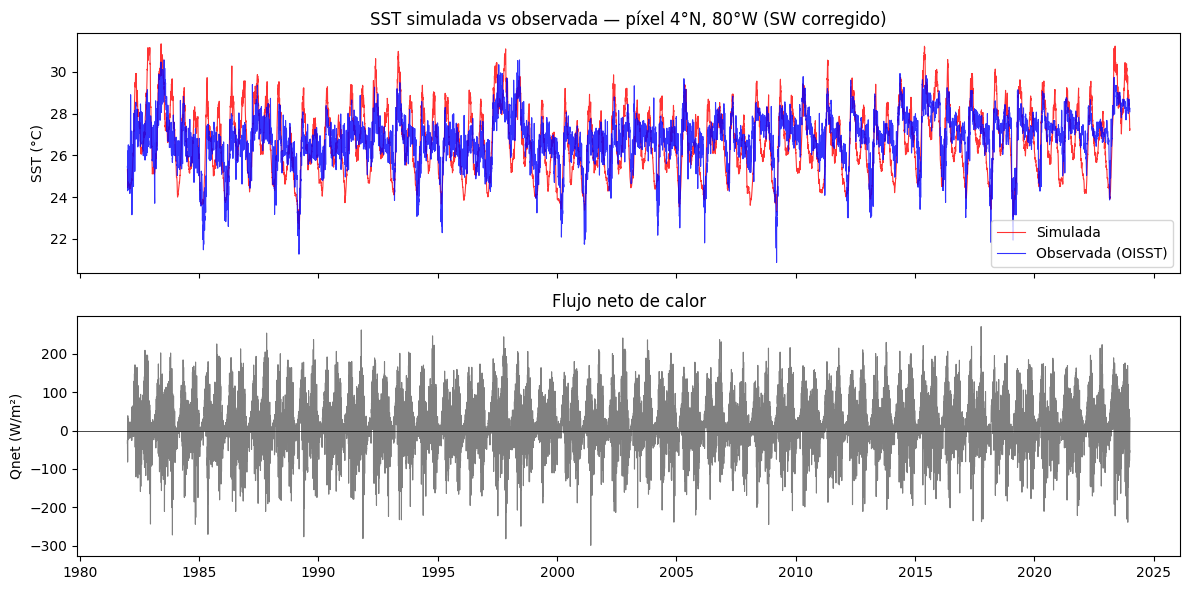

RMSE: 1.22 °C
Bias: -0.11 °C
Correlación: 0.659


In [29]:

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

tiempo_plot = oisst.time.values

axes[0].plot(tiempo_plot, sst_sim, label="Simulada", color="red", lw=0.8, alpha=0.8)
axes[0].plot(tiempo_plot, sst_obs, label="Observada (OISST)", color="blue", lw=0.8, alpha=0.8)
axes[0].set_ylabel("SST (°C)")
axes[0].legend()
axes[0].set_title("SST simulada vs observada — píxel 4°N, 80°W (SW corregido)")

axes[1].plot(tiempo_plot, qnet, color="gray", lw=0.8)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_ylabel("Qnet (W/m²)")
axes[1].set_title("Flujo neto de calor")

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((sst_sim - sst_obs)**2))
bias = np.mean(sst_sim - sst_obs)
corr = np.corrcoef(sst_obs, sst_sim)[0, 1]
print(f"RMSE: {rmse:.2f} °C")
print(f"Bias: {bias:.2f} °C")
print(f"Correlación: {corr:.3f}")